
ARIMA Time Series


Stationarity testing (ADF)

ARIMA modeling

Walk-forward validation

RMSE / MAE evaluation

Naive baseline comparison


In [ ]:

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA


In [26]:
data = yf.download("AAPL", start="2020-01-01", end="2024-01-01")
prices = data['Close']
returns = prices.pct_change().dropna()

[*********************100%***********************]  1 of 1 completed


In [27]:
train_size = int(len(returns) * 0.8)
train, test = returns[:train_size], returns[train_size:]

In [28]:
train = train.squeeze().astype(float).dropna()
test = test.squeeze().astype(float).dropna()
# ADF Test
result = adfuller(train)
print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -9.049155367923486
p-value: 4.8932122687903284e-15


In [ ]:
# Walk-forward ARIMA
import warnings
warnings.filterwarnings("ignore")
history = train.values.flatten().tolist()
predictions = []

for t in range(len(test)):
    history_array = np.array(history, dtype=float)

    model = ARIMA(history_array, order=(1,0,1))
    model_fit = model.fit()

    yhat = float(model_fit.forecast()[0])
    predictions.append(yhat)

    actual = float(test.iloc[t])
    history.append(actual)

In [30]:
# Evaluation
predictions = np.array(predictions)
test_vals = test.values[:len(predictions)]

rmse = np.sqrt(np.mean((test_vals - predictions) ** 2))
mae = np.mean(np.abs(test_vals - predictions))

print("ARIMA RMSE:", rmse)
print("ARIMA MAE:", mae)

ARIMA RMSE: 0.011980943819548139
ARIMA MAE: 0.00908232612301341


In [31]:
# Naive baseline
naive_preds = test.shift(1).dropna().values
aligned_test = test[1:].values

naive_rmse = np.sqrt(np.mean((aligned_test - naive_preds) ** 2))

print("Naive RMSE:", naive_rmse)

Naive RMSE: 0.01601980781731854


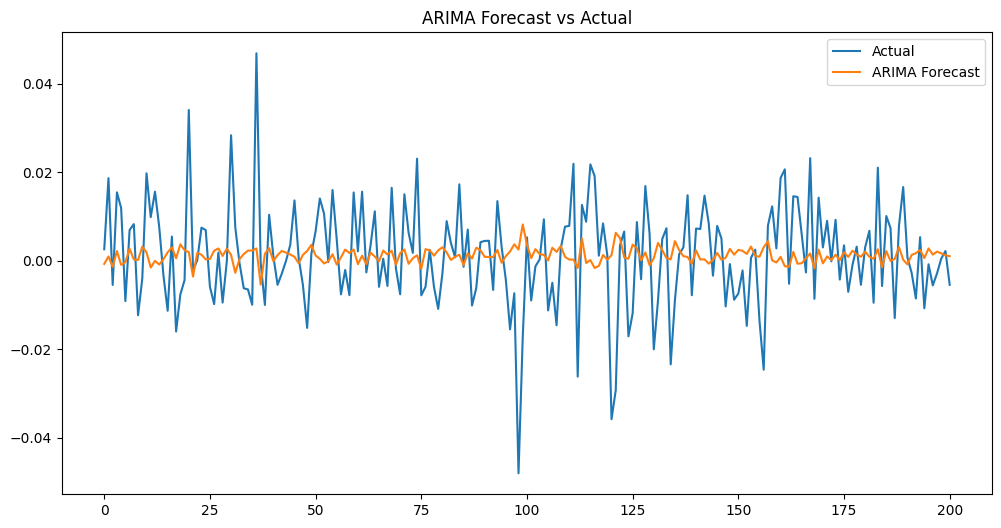

In [32]:
plt.figure(figsize=(12,6))
plt.plot(test_vals, label="Actual")
plt.plot(predictions, label="ARIMA Forecast")
plt.legend()
plt.title("ARIMA Forecast vs Actual")
plt.show()